# Sensitivity Analysis

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../../../code')  # for imports from root-level `libs`

%load_ext autoreload
%autoreload 2

from libs.utils import ios
from libs.metrics.constants import *

from libs.sensitivity import (
    ModelSpec,
    ModelSpec, SensitivityAnalysis
)

from libs.visuals.sensitivity_heatmap import GroupedSensitivityHeatmap
from libs.visuals.vis import sns_paper_style
from libs.metrics.constants import *
from libs.visuals.constants import *

In [3]:
ROOT = '../../../'
RESULTS_DIR = ios.path_join(ROOT, 'results')
FN_VALID_REQUESTS = ios.path_join(RESULTS_DIR, 'summary', 'valid_requests_metadata.csv')

SENSITIVITY_ANALYSIS_DIR = ios.path_join(RESULTS_DIR, 'sensitivity_analysis')
ios.validate_path(SENSITIVITY_ANALYSIS_DIR)

PATH_RESULTS = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'sensitivity_v4/')
ios.validate_path(PATH_RESULTS)

PATH_PLOTS = ios.path_join(PATH_RESULTS, 'plots')
ios.validate_path(PATH_PLOTS)

FN_SA_BY_PROMPT_VAR = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_variable.csv')
FN_SA_BY_PROMPT_TYPE = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_type.csv')
FN_SA_BY_MODEL_KIND = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_kind.csv')

METRICS_TO_EXCLUDE = ['popularity_works', 'popularity_citations']

In [4]:
df_valid_requests = ios.load_csv(FN_VALID_REQUESTS)
df_valid_requests.shape

(928800, 52)

In [5]:
df_valid_requests.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,...,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


In [6]:
df_valid_requests.columns

Index(['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield',
       'language', 'run_id', 'model_access', 'model_size', 'model_class',
       'model_family', 'model_short_name', 'validity', 'refusals',
       'n_total_recommendations', 'n_unique_authors', 'n_authors_found',
       'duplicates', 'factuality_author', 'factuality_field',
       'factuality_seniority', 'factuality_location', 'div_ethnicity',
       'div_gender', 'div_location', 'parity_ethnicity', 'parity_gender',
       'pct_works_low', 'pct_works_med', 'pct_works_high',
       'div_productivity_works', 'pct_citations_low', 'pct_citations_med',
       'pct_citations_high', 'div_productivity_citations', 'parity_works',
       'parity_citations', 'popularity_works', 'popularity_citations',
       'consistency', 'language_en', 'location_en', 'field_en', 'subfield_en',
       'task_en', 'target_en', 'role_en', 'duplicates_c', 'refusals_c'],
      dtype='object')

In [7]:
prompt_vars = list(PROMPT_TYPE_MAP.keys())
llm_col = "model"  
llm_familty_col = "model_family"  

# Pre-processing
Checking for colinearity, etc

## Colinearity test

In [8]:
for fam, dfg in df_valid_requests.groupby("model_family"):
    print("\nFAMILY:", fam)
    print("rows:", len(dfg))
    print("models:", dfg["model"].nunique())

    for v in prompt_vars:
        print(v, "levels:", dfg[v].nunique())


FAMILY: deepseek
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: dolphin
rows: 86400
models: 4
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: falcon
rows: 43200
models: 2
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemini
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemma
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gpt-4
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_e

In [9]:
# Checking sparse levels
for fam, dfg in df_valid_requests.groupby("model_family"):

    for v in prompt_vars:
        counts = dfg[v].value_counts()
        sparse = counts[counts < 5]

        if len(sparse) > 0:
            print("\nFAMILY:", fam, "\n", v)
            print(sparse)

In [10]:
# Checking whether prompt variables are confounded
import pandas as pd
pd.crosstab(
    df_valid_requests["role_en"],
    df_valid_requests["field_en"]
)

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
role_en,,,,,,
Director/Recruiter,77400,77400,77400,77400,77400,77400
PhD student,77400,77400,77400,77400,77400,77400


In [11]:
fam = "gemini"
dfg = df_valid_requests[df_valid_requests["model_family"] == fam]
pd.crosstab(dfg["language_en"], dfg["field_en"])

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
language_en,,,,,,
English,3600,3600,3600,3600,3600,3600
German,3600,3600,3600,3600,3600,3600
Spanish,3600,3600,3600,3600,3600,3600


# Modeling

For each metric, how much sensitivity is associated with persona vs context variables?

How much variance in each metric is attributable to persona vs context prompting.

|partial η²	| Interpretation |
|---|---|
|< 0.01	| very small |
|0.01–0.06 |	small |
|0.06–0.14 |	moderate |
|> 0.14 |	large |

## Data

In [12]:
base_spec = ModelSpec(
    persona_vars=PROMPT_VAR_GROUPS['persona'],
    context_vars=PROMPT_VAR_GROUPS['context'],
    llm_attrs=['model_size', 'model_access', 'model_class'],
    llm_id='model'
)

analysis = SensitivityAnalysis(all_metrics=ALL_METRICS, 
                               metrics_to_exclude=METRICS_TO_EXCLUDE,
                               base_spec=base_spec)

# 0. special caase (model_access does not have XL)
df_valid_requests_clean = df_valid_requests.copy()
df_valid_requests_clean.loc[:,'model_size_collapsed'] = df_valid_requests_clean.model_size.replace({'XL':'L'})

# 1. Data prep (once)
df_valid_requests_clean = analysis.prepare_data(
                                df_valid_requests_clean,
                                dropna = False,
                                categorical_llm_group_refs={'model_size': 'L', 
                                                            'model_access': 'open-weight', 
                                                            'model_class': False},
                                categorical_prompt_var_refs={'field_en': 'Physics', 
                                                            'k':1.0,
                                                            'language_en': 'English', 
                                                            'location_en': 'Germany', 
                                                            'subfield_en':'Education', 
                                                            'role_en':'Director/Recruiter', 
                                                            'target_en':'Junior Professor'}
                            )

Setting reference level for model_size: L
Setting reference level for model_access: open-weight
Setting reference level for model_class: False
Setting reference level for language_en: English
Setting reference level for location_en: Germany
Setting reference level for role_en: Director/Recruiter
Setting reference level for k: 1.0
Setting reference level for field_en: Physics
Setting reference level for subfield_en: Education
Setting reference level for target_en: Junior Professor

Prepared dataframe: N = 928,800 rows, 23 metrics, 7 prompt vars 0 structural vars.


## Model 1: 
Fixed effects

In [ ]:
# 2. Fit Model 1 for everything
analysis.fixed_effects_model()

# 3. Fit Model 2 — skip metrics where it's not needed
# analysis.mixed_effects_model(metrics_to_exclude=METRICS_TO_EXCLUDE)

# 4. Save
analysis.save(PATH_RESULTS)

# Plots

## General effects

In [13]:
sns_paper_style(font_scale=1.51)

In [14]:
ROW_GROUPS = PROMPT_VAR_GROUPS
COL_GROUPS = EVALUATION_METRIC_GROUPS

FIG_DPI = 300
FIG_WIDTH = 15
FIG_HEIGHT = 0.8

In [15]:
NAME_MAP = PLOT_LABELS | {'role_en': 'Role', 
                          'location_en': 'Location', 
                          'language_en': 'Language',
                          'k': 'k', 
                          'field_en': 'Field', 
                          'subfield_en': 'Subfield',
                          'target_en': 'Target',
                          'model': 'Model'
                          }

NAME_MAP |= {c:c.replace('factuality_','').replace('div_','').replace('pct_works_','').replace('pct_citations_','').replace('parity_','').replace('low','T1').replace('med','T2').replace('high','T3').title() 
             for c in ALL_METRICS if c.startswith('parity_') or c.startswith('pct_') or c.startswith('div_') or c.startswith('factuality_')}


In [16]:
# Thin reload (no refit, but saved tables are accessible)
analysis = SensitivityAnalysis.load(PATH_RESULTS)

Loaded analysis from ../../../results/sensitivity_analysis/sensitivity_v4/ — 23 metrics, df not provided


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/sensitivity_by_source_of_variation.pdf


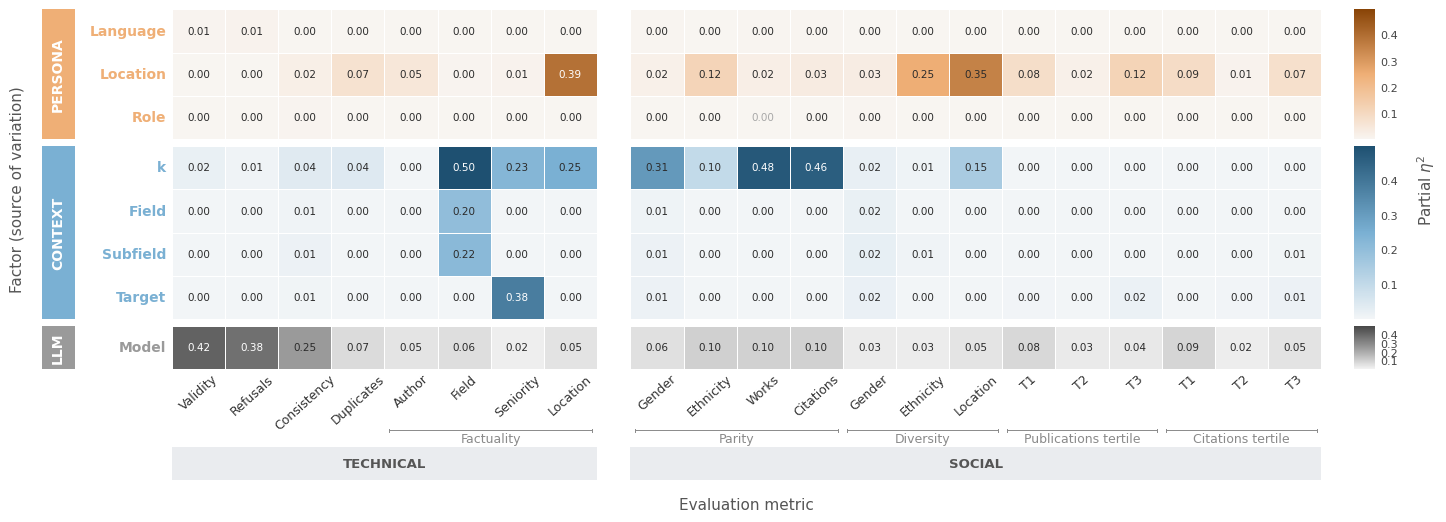

In [17]:

plot = GroupedSensitivityHeatmap.from_long(
    anova_df=analysis.effects,
    row_col='variable',
    col_col='metric',
    value_col='partial_eta2',
    pvalue_col='p_value',

    row_groups=ROW_GROUPS,
    col_groups=COL_GROUPS,
    row_group_colors=PROMPT_VAR_COLORS,
    name_map=NAME_MAP, 

    # text — pass None to hide any of these
    figsize=(FIG_WIDTH, 5.2),
    title=None,
    xlabel='Evaluation metric',
    ylabel='Factor (source of variation)',
    annot_threshold=0.0,

    tick_prefix_groups = PREFIX_GROUPS_METRICS,

    # element toggles
    show_colorbar_labels=False,   # the PERSONA / CONTEXT text above each cbar
    show_col_group_labels=True,   # the TECHNICAL / SOCIAL text
    show_row_group_bands=True,    # the orange/blue side bands
    show_colorbars=True,

    # margins (None = auto, computed from what's shown)
    left=None, right=None, top=None, bottom=None,

    significance_style='dim',
    significance_threshold=0.05,
)
fig = plot.draw()
fig.tight_layout()
fn = ios.path_join(PATH_PLOTS, 'sensitivity_by_source_of_variation.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')


# Main effects

In [18]:
from libs.visuals.sensitivity import *

In [19]:
VARS = {'technical': [c for c in METRIC_TYPES['technical'] if not c.startswith('factuality_')],
        'factuality': [c for c in METRIC_TYPES['technical'] if c.startswith('factuality_')],
        'parity': PARITY_METRICS,
        'diversity': DIVERSITY_METRICS,
        'popularity': [c for c in POPULARITY_METRICS if c not in METRICS_TO_EXCLUDE],
        }

Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/main_effects_by_technical_variable.pdf


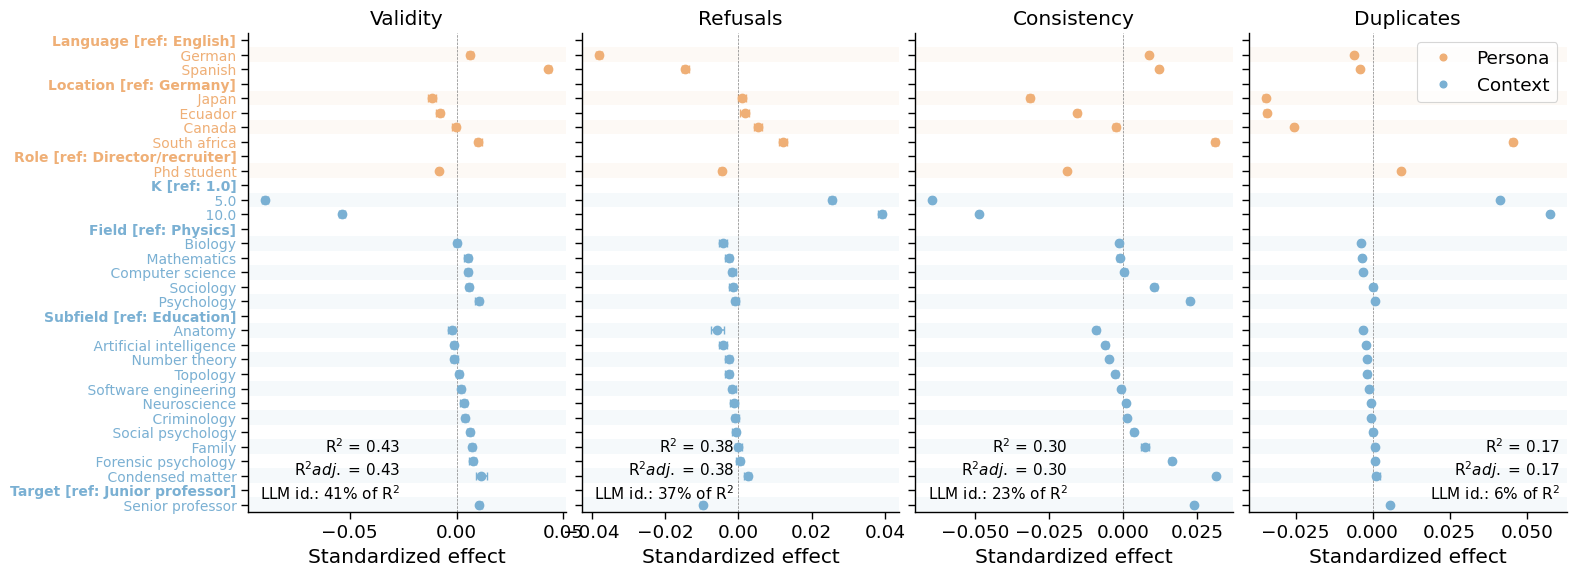

In [20]:
kind = 'technical'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map={'field_en':'Field', 'subfield_en':'Subfield', 'role_en':'Role', 'location_en':'Location', 'language_en':'Language','target_en':'Target'},
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric not in ['factuality_field','factuality_seniority','duplicates'] else 0.98, 'ha': 'right'},
                         )
    ax.set_title(metric.title().replace('_',' '))
    ax.set_xlabel(f'Standardized effect' if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/main_effects_by_factuality_variable.pdf


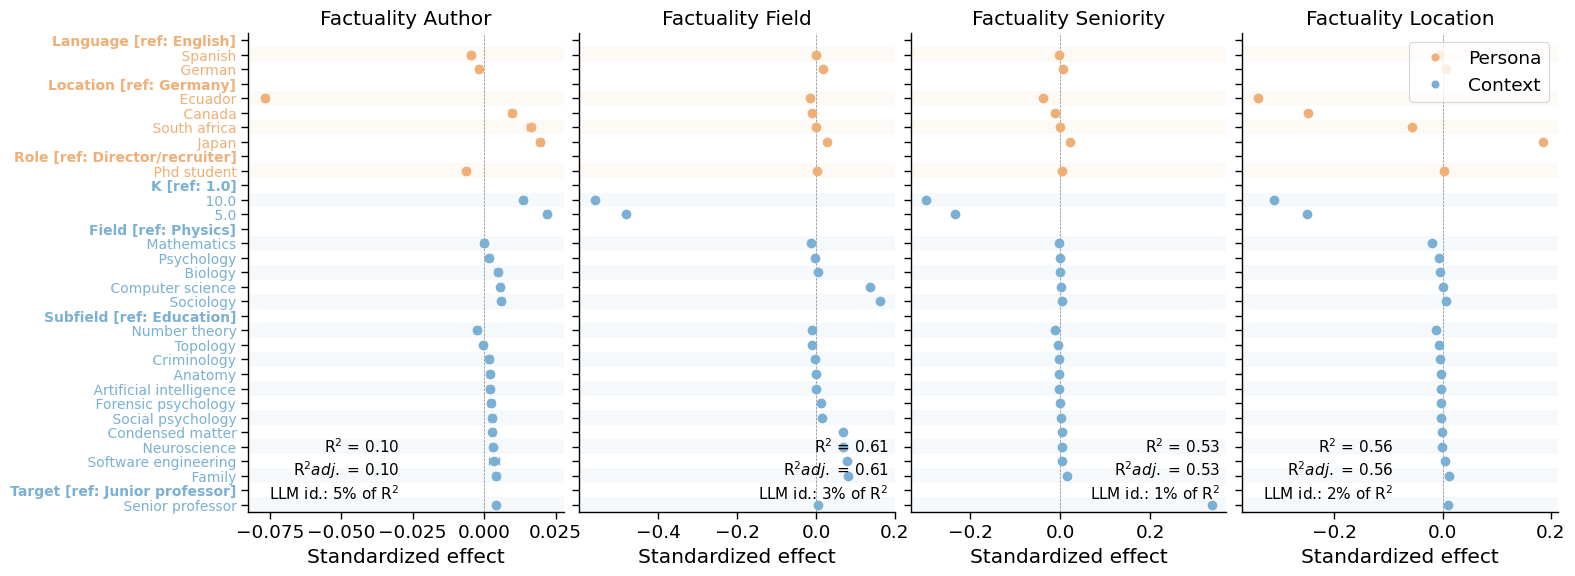

In [21]:
kind = 'factuality'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map={'field_en':'Field', 'subfield_en':'Subfield', 'role_en':'Role', 'location_en':'Location', 'language_en':'Language','target_en':'Target'},
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.48 if spec.metric not in ['factuality_field','factuality_seniority','duplicates'] else 0.98, 'ha': 'right'},
                         )
    ax.set_title(metric.title().replace('_',' '))
    ax.set_xlabel(f'Standardized effect' if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/main_effects_by_parity_variable.pdf


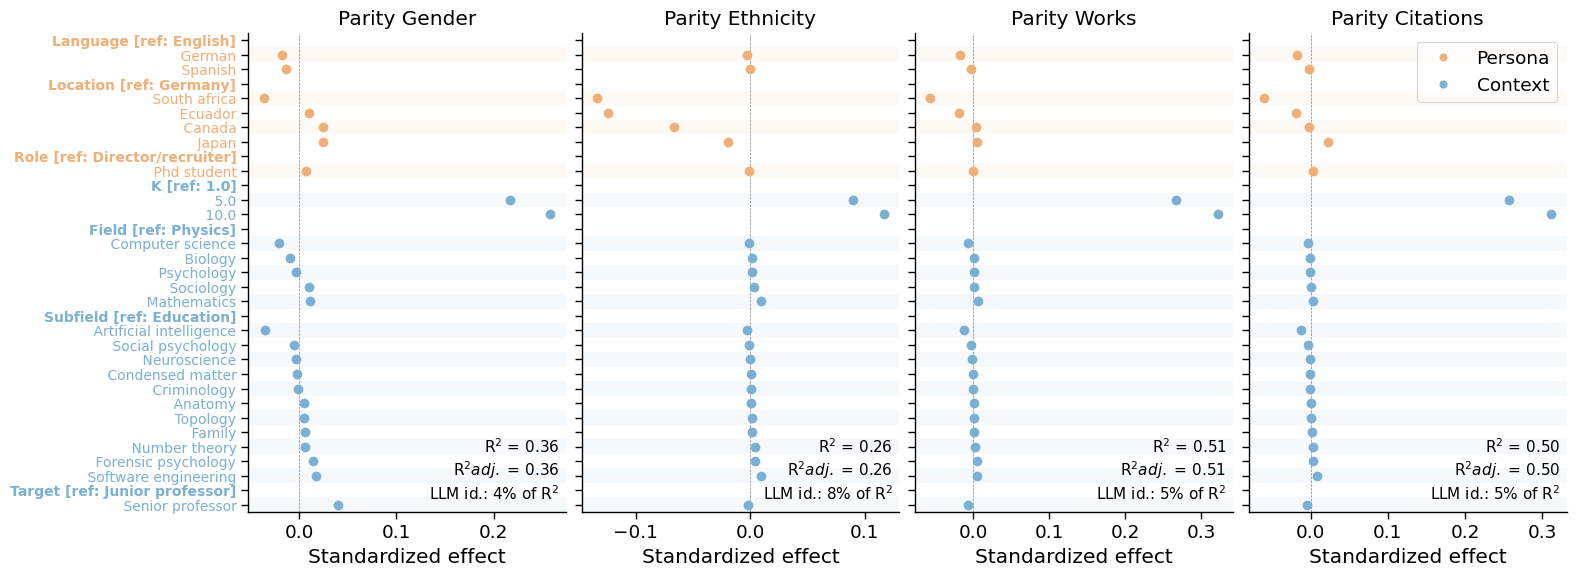

In [22]:
kind = 'parity'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map={'field_en':'Field', 'subfield_en':'Subfield', 'role_en':'Role', 'location_en':'Location', 'language_en':'Language','target_en':'Target'},
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x':0.98},
                         )
    ax.set_title(metric.title().replace('_',' '))
    ax.set_xlabel(f'Standardized effect' if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/main_effects_by_diversity_variable.pdf


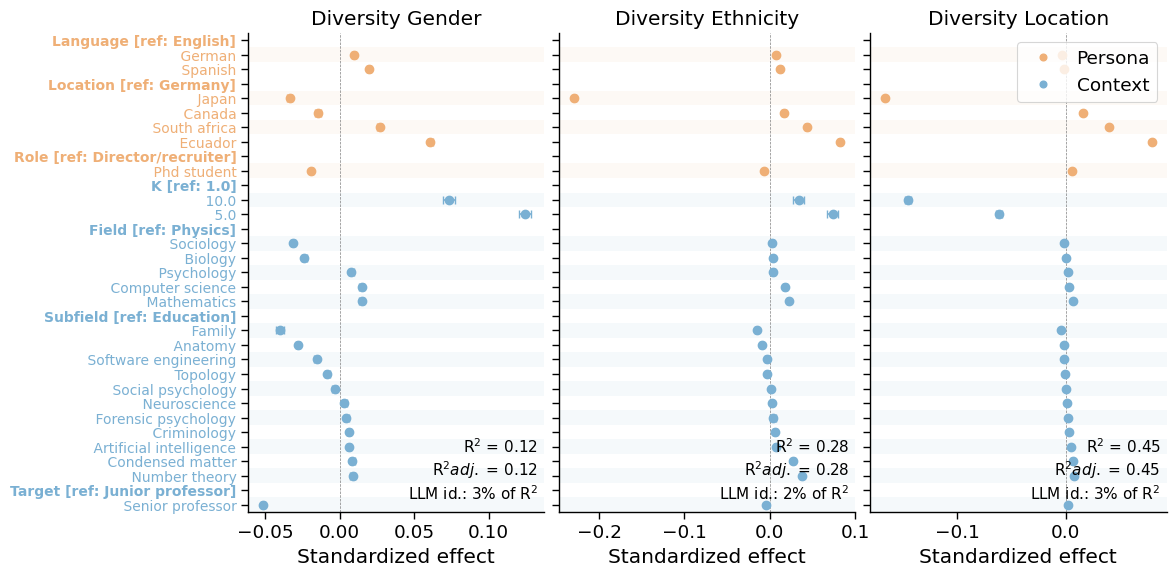

In [23]:
kind = 'diversity'
nrows = 1
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map={'field_en':'Field', 'subfield_en':'Subfield', 'role_en':'Role', 'location_en':'Location', 'language_en':'Language','target_en':'Target'},
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x':0.98},
                         )
    ax.set_title(metric.replace('div_','Diversity ').title())
    ax.set_xlabel(f'Standardized effect' if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


Saved plot to: ../../../results/sensitivity_analysis/sensitivity_v4/plots/main_effects_by_popularity_variable.pdf


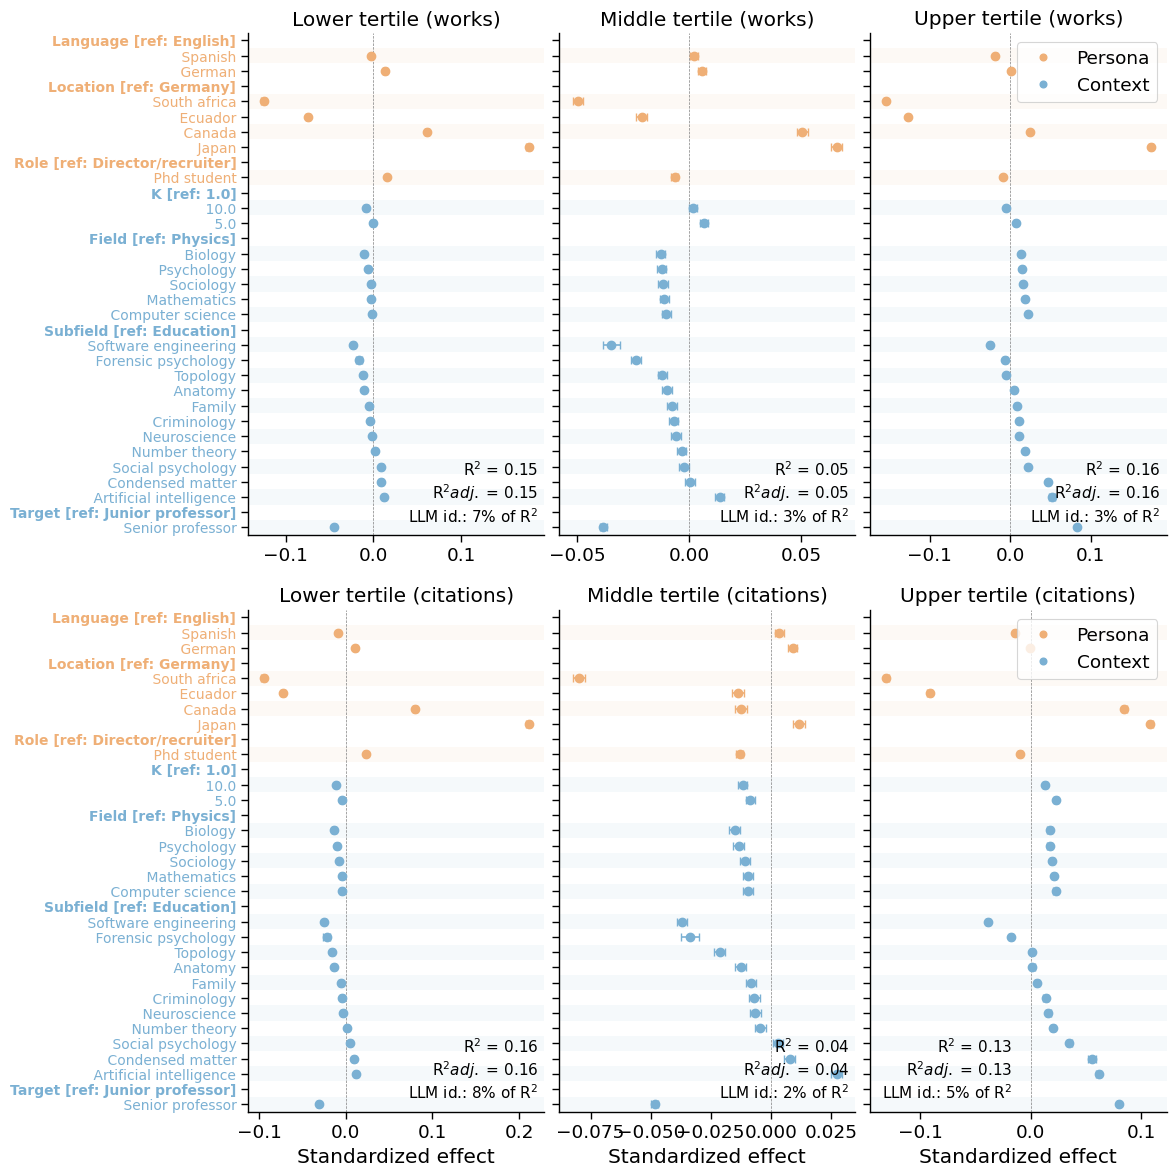

In [24]:
kind = 'popularity'
pct_map = {'pct_works_high': 'Upper tertile (works)',  
           'pct_citations_high': 'Upper tertile (citations)',
           'pct_works_med': 'Middle tertile (works)',  
           'pct_citations_med': 'Middle tertile (citations)',
           'pct_works_low': 'Lower tertile (works)',  
           'pct_citations_low': 'Lower tertile (citations)',
           }
nrows = 2
fig,grid = create_grid(analysis.results, metrics=VARS[kind], nrows=nrows, figsize_per_panel=(4,6))
for metric, obj in grid.items():
    ax = obj['ax']
    model = analysis.results[metric]['m1']
    spec = model.spec
    _ = plot_main_effects(model, 
                         df=df_valid_requests_clean,
                         spec=spec, ax=ax, title = 'Average effect across LLMs', 
                         name_map={'field_en':'Field', 'subfield_en':'Subfield', 'role_en':'Role', 'location_en':'Location', 'language_en':'Language','target_en':'Target'},
                         figsize=(FIG_WIDTH, 6),
                         r2_kwargs={'x': 0.98 if spec.metric not in ['pct_citations_high'] else 0.48},
                         )
    ax.set_title(pct_map.get(metric, metric.title().replace('_',' ')))
    ax.set_xlabel(f'Standardized effect' if obj['irow'] == nrows-1 else '')
    if obj['icol'] <= obj['ncols']-2:
        ax.legend().remove()
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
fn = ios.path_join(PATH_PLOTS, f'main_effects_by_{kind}_variable.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(f'Saved plot to: {fn}')
plt.show()
plt.close()


# Mixed effects
**ICC**
| ICC | Interpretation |
|---|---|
| < 0.50 | Poor reliability |
| 0.50 – 0.75 | Moderate reliability
| 0.75 – 0.90 | Good reliability
| > 0.90 | Excellent reliability |